In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering ,MeanShift,OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA


DBSCAN 
from sklearn.cluster import DBSCAN

👉 Best for:
Noise detection
Irregular shapes
----------------------------------------
Mean Shift
from sklearn.cluster import MeanShift

👉 Features:

No need to specify clusters
Automatically finds clusters

👉 Use when:

You don’t know number of clusters
-------------------------------------------
OPTICS (Advanced DBSCAN)

from sklearn.cluster import OPTICS

👉 Features:

Handles varying density
Better than DBSCAN in some cases

In [2]:
df = pd.read_csv("student_clustering.csv")


In [3]:
df.head()


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [4]:
df.isnull().sum()


cgpa    0
iq      0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(7)

In [6]:
df.shape


(200, 2)

In [7]:
# find outliers using IQR method or quantile
# q1 = df[['cgpa','iq']].quantile(0.25)
# q3 = df[['cgpa','iq']].quantile(0.75)

# iqr = q3-q1

# lower = q1-1.5*iqr
# upper = q3+1.5*iqr


# outliers = df[
#     (df['cgpa']<lower['cgpa']) | (df['cgpa']>upper['cgpa']) |
#     (df['iq']<lower['iq']) | (df['iq']>upper['iq'])]

# print(outliers)


In [8]:
# df.loc[200] = [20,300]


In [9]:
# Remove outliers from dataset 
# clean_df = df[
#           (df['cgpa']>=lower['cgpa'])  & (df['cgpa']<=upper['cgpa'])  &
#           (df['iq']>=lower['iq'])  & (df['iq']<=upper['iq']) 
#           ]
# clean_df.shape


In [10]:
# clean_df = df[~((df < lower) | (df > upper)).any(axis=1)]
# clean_df.shape
# # 


In [11]:
ss = StandardScaler()
x = ss.fit_transform(df[['cgpa','iq']])


In [12]:
# df.loc work with rows and columns but we need to mentions row index number and columns name 
df.loc[0:2,['iq','cgpa']]


,iq,cgpa
0,88,5.13
1,113,5.90
2,93,8.36


In [13]:
#  df.iloc work with rows and collumns index both, we need to mentions columns and index both index number as integer 
df.iloc[0:5:2,0:2]


,cgpa,iq
0,5.13,88
2,8.36,93
4,5.45,110


In [25]:
import pickle
km = KMeans(n_clusters=10,random_state=42,n_init=10)
km.fit(x)
label = km.fit_predict(x)
df['cluster'] = label

pickle.dump(km,open('unmodel.pkl','wb'))
pickle.dump(ss,open('unscaler.pkl','wb'))


In [15]:

df['cluster'].value_counts()


cluster
2    50
4    23
0    19
5    18
6    18
3    17
8    17
1    15
7    15
9     8
Name: count, dtype: int64

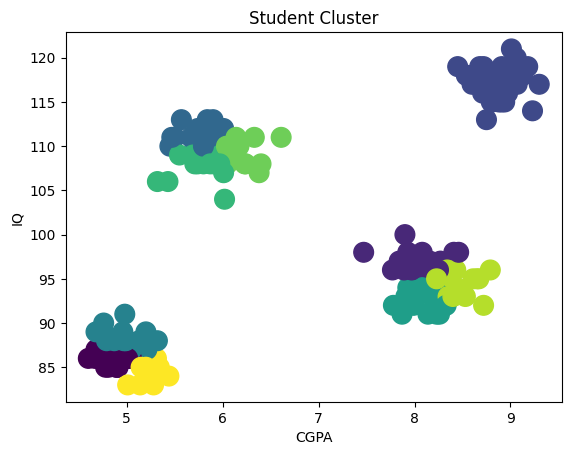

In [16]:
plt.scatter(df['cgpa'],df['iq'],c=df['cluster'],s=200,cmap='viridis')
center = ss.inverse_transform(km.cluster_centers_)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Student Cluster')
plt.show()


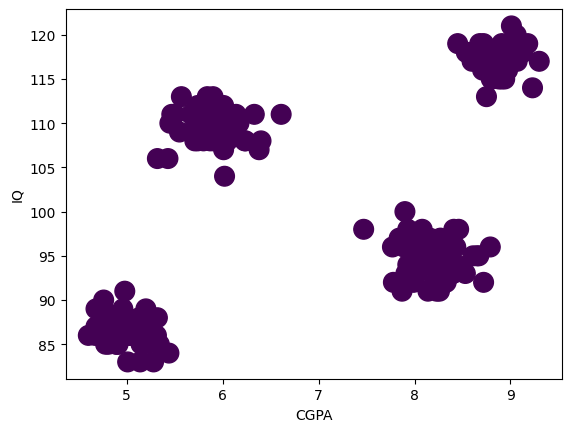

In [ ]:

# now we start working with DBSCAN algorithem
dbscan = DBSCAN(eps=3,min_samples=5)
label1 = dbscan.fit_predict(x)
plt.xlabel('CGPA')
plt.ylabel('IQ')
df['cluster'] = label1

plt.scatter(df['cgpa'],df['iq'],c= df['cluster'],s=200)
plt.show()


In [ ]:
import streamlit as st 
st.write('Noise Point', df[df['cluster'] == -1])

if km == "KMeans":
    centers = ss.inverse_transform(km.cluster_centers_)
    plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)


2026-04-01 15:17:39.200 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.369 
  command:

    streamlit run C:\Users\harey\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-01 15:17:40.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.372 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.377 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 15:17:40.409 Thre